In [11]:
import cv2
import numpy as np
import os

def apply_field_degradation(img, skew_angle=12.0, shadow_intensity=0.6):
    """Simulate a bad smartphone photo: skew + uneven shadow.
    Takes a BGR image array, returns a degraded BGR array."""
    h, w = img.shape[:2]

    # 1. Skew (rotation) with white fill
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, skew_angle, 1.0)
    skewed = cv2.warpAffine(img, M, (w, h), borderValue=(255, 255, 255))

    # 2. Shadow gradient, vectorized, built as 3-channel directly with numpy
    yy, xx = np.mgrid[0:h, 0:w]
    dist = np.minimum(xx, yy) / float(min(w, h))
    factor = 1.0 - dist * shadow_intensity
    factor = np.clip(factor, 0.0, 1.0).astype(np.float32)
    factor3 = np.repeat(factor[:, :, np.newaxis], 3, axis=2)  # (h,w) -> (h,w,3)

    degraded = (skewed.astype(np.float32) * factor3).astype(np.uint8)
    return degraded

In [18]:
def deskew_angle(gray, max_skew=20.0, step=0.5):
    """Projection-profile deskew: find the angle that makes text rows sharpest.
    Robust on single-line and multi-line text, unlike minAreaRect."""
    # Binarize just for the angle search (not for output)
    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    h, w = thresh.shape
    center = (w // 2, h // 2)

    best_angle = 0.0
    best_score = -1.0

    # Search candidate angles in [-max_skew, +max_skew]
    angles = np.arange(-max_skew, max_skew + step, step)
    for ang in angles:
        M = cv2.getRotationMatrix2D(center, ang, 1.0)
        rotated = cv2.warpAffine(thresh, M, (w, h),
                                 flags=cv2.INTER_NEAREST, borderValue=0)
        # Sum dark pixels per row -> projection profile
        row_sums = np.sum(rotated, axis=1)
        # Sharpness = variance of the profile (peaky = high variance)
        score = np.var(row_sums)
        if score > best_score:
            best_score = score
            best_angle = ang

    return best_angle

def recover_document(degraded_img):
    """CLAHE for illumination + deskew. NO hard binarization (protects diacritics)."""
    gray = cv2.cvtColor(degraded_img, cv2.COLOR_BGR2GRAY)

    # 1. Illumination recovery via CLAHE (contrast, not binarization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    illuminated = clahe.apply(gray)

    # 2. Deskew: find angle, rotate the ILLUMINATED grayscale (not the threshold)
    angle = deskew_angle(illuminated)
    h, w = illuminated.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    recovered = cv2.warpAffine(illuminated, M, (w, h),
                               borderMode=cv2.BORDER_REPLICATE)

    return recovered, angle

Applied skew: 12.0 deg  |  Estimated/corrected angle: 0.0 deg


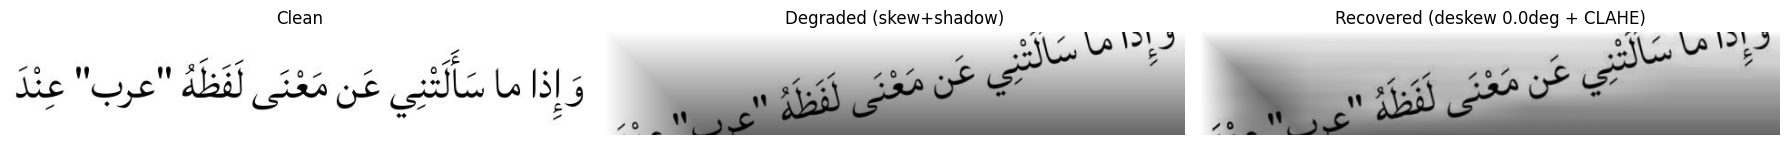

In [19]:
import matplotlib.pyplot as plt
from datasets import load_dataset

ds = load_dataset("ahmedheakl/arocrbench_synthesizear", split="train")

# Take one clean sample, convert PIL -> BGR numpy
sample = ds[0]
clean_bgr = cv2.cvtColor(np.array(sample["image"].convert("RGB")), cv2.COLOR_RGB2BGR)

degraded = apply_field_degradation(clean_bgr, skew_angle=12.0, shadow_intensity=0.6)
recovered, est_angle = recover_document(degraded)

print(f"Applied skew: 12.0 deg  |  Estimated/corrected angle: {est_angle:.1f} deg")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("Clean"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)); axes[1].set_title("Degraded (skew+shadow)"); axes[1].axis("off")
axes[2].imshow(recovered, cmap="gray"); axes[2].set_title(f"Recovered (deskew {est_angle:.1f}deg + CLAHE)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

In [17]:
sample = ds[0]
print("PIL image:", sample["image"], "| mode:", sample["image"].mode, "| size:", sample["image"].size)

clean_bgr = cv2.cvtColor(np.array(sample["image"].convert("RGB")), cv2.COLOR_RGB2BGR)
print("clean_bgr shape:", clean_bgr.shape, "| dtype:", clean_bgr.dtype)

degraded = apply_field_degradation(clean_bgr, skew_angle=12.0, shadow_intensity=0.6)
print("degraded:", None if degraded is None else (degraded.shape, degraded.dtype))

PIL image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=639x114 at 0x2BB770F7F90> | mode: RGB | size: (639, 114)
clean_bgr shape: (114, 639, 3) | dtype: uint8
degraded: ((114, 639, 3), dtype('uint8'))


In [20]:
_, thresh = cv2.threshold(
    cv2.cvtColor(degraded, cv2.COLOR_BGR2GRAY), 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
h, w = thresh.shape
center = (w // 2, h // 2)

for ang in [-12, -8, -4, 0, 4, 8, 12]:
    M = cv2.getRotationMatrix2D(center, ang, 1.0)
    rotated = cv2.warpAffine(thresh, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)
    score = np.var(np.sum(rotated, axis=1))
    print(f"angle {ang:+d}: variance {score:,.0f}")

angle -12: variance 774,307,598
angle -8: variance 1,514,778,069
angle -4: variance 2,940,020,101
angle +0: variance 4,572,302,343
angle +4: variance 2,835,653,970
angle +8: variance 1,179,752,203
angle +12: variance 313,860,124


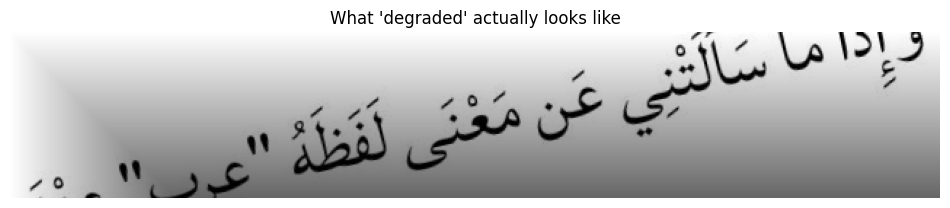

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,3))
plt.imshow(cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB))
plt.title("What 'degraded' actually looks like")
plt.axis("off"); plt.show()

Page shape: (984, 1262, 3)


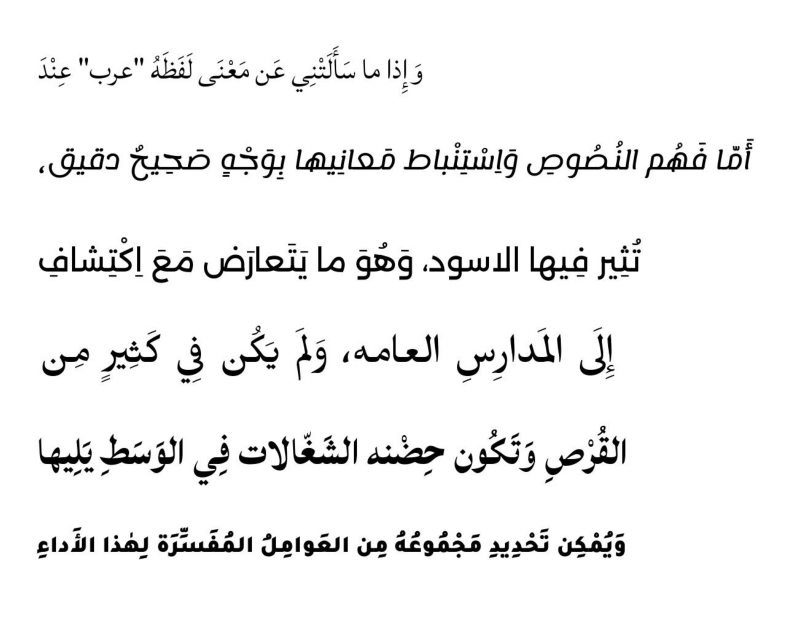

In [22]:
def make_multiline_page(ds, indices, gap=15, pad=40):
    """Stack several single-line KITAB images into one multi-line page."""
    strips = []
    maxw = 0
    for i in indices:
        s = np.array(ds[i]["image"].convert("RGB"))
        strips.append(s)
        maxw = max(maxw, s.shape[1])
    # pad each strip to same width (white), stack with gaps
    rows = []
    for s in strips:
        h, w = s.shape[:2]
        if w < maxw:
            s = cv2.copyMakeBorder(s, 0, 0, 0, maxw - w, cv2.BORDER_CONSTANT, value=(255,255,255))
        rows.append(s)
        rows.append(np.full((gap, maxw, 3), 255, np.uint8))  # white gap
    page = np.vstack(rows[:-1])  # drop last gap
    # white margin around the whole page
    page = cv2.copyMakeBorder(page, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=(255,255,255))
    return page

# Build a 6-line page and also keep the concatenated ground truth
page_indices = [0, 1, 2, 5, 7, 9]
page = make_multiline_page(ds, page_indices)
page_gt = " ".join(ds[i]["text"] for i in page_indices)
print("Page shape:", page.shape)  # should be tall now, not a thin strip

plt.figure(figsize=(10,8)); plt.imshow(cv2.cvtColor(page, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

Applied 12 deg | Estimated/corrected: -12.0 deg


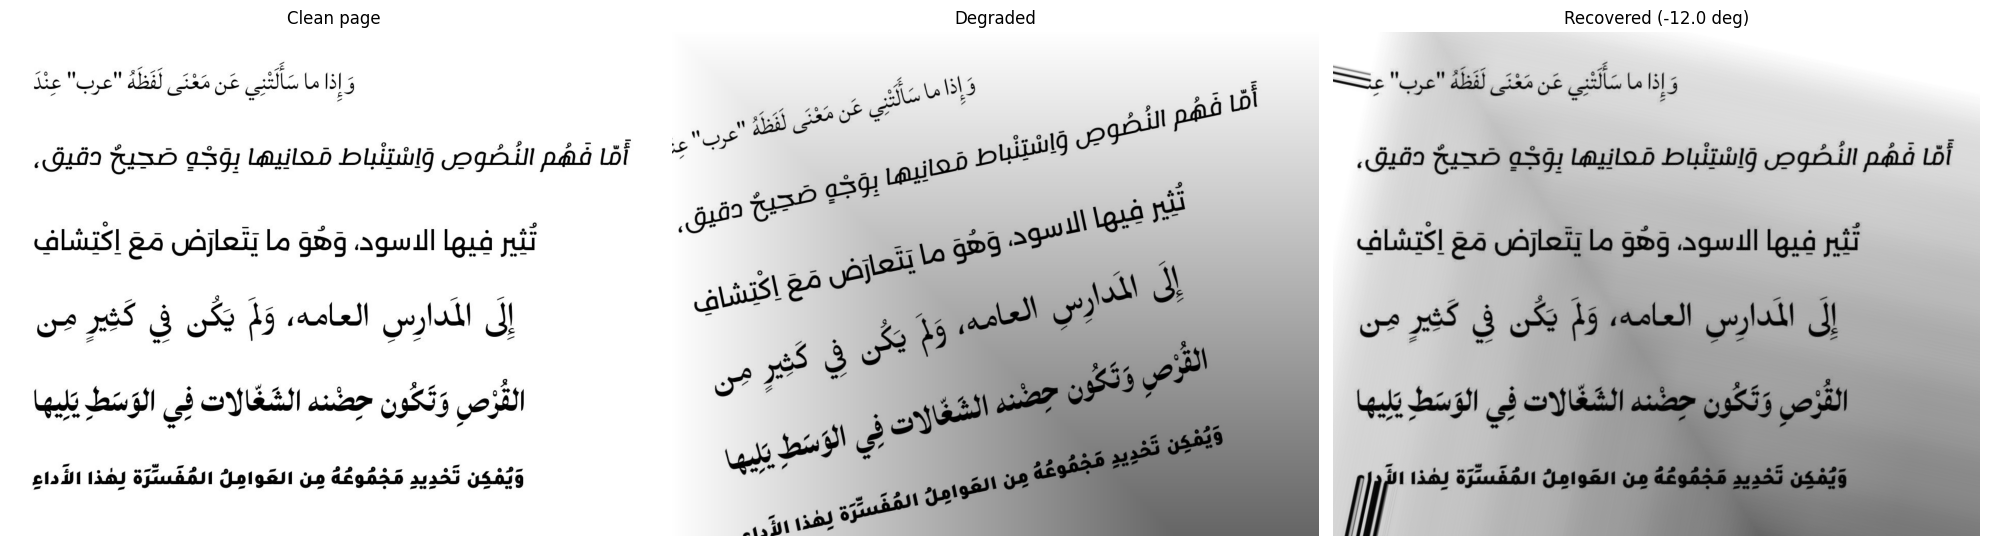

In [23]:
# Degrade the multi-line page and check the deskew finds the angle
page_degraded = apply_field_degradation(page, skew_angle=12.0, shadow_intensity=0.6)
page_recovered, est = recover_document(page_degraded)
print(f"Applied 12 deg | Estimated/corrected: {est:.1f} deg")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
ax[0].imshow(cv2.cvtColor(page, cv2.COLOR_BGR2RGB)); ax[0].set_title("Clean page"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(page_degraded, cv2.COLOR_BGR2RGB)); ax[1].set_title("Degraded"); ax[1].axis("off")
ax[2].imshow(page_recovered, cmap="gray"); ax[2].set_title(f"Recovered ({est:.1f} deg)"); ax[2].axis("off")
plt.tight_layout(); plt.show()

In [25]:
from PIL import Image
from pathlib import Path
import time
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import pyarabic.araby as araby

# Reload the image
image_path = Path("../data/inputs/test_arabic_01.png")
print(f"Image exists: {image_path.exists()}")
print(f"Resolved path: {image_path.resolve()}")

image = Image.open(image_path)
print(f"Image size: {image.size}")
image

from surya.foundation import FoundationPredictor
from surya.recognition import RecognitionPredictor
from surya.detection import DetectionPredictor

# Load Surya's two main components
foundation_predictor = FoundationPredictor()
recognition_predictor = RecognitionPredictor(foundation_predictor)
detection_predictor = DetectionPredictor()

print("Surya loaded.")

Image exists: True
Resolved path: C:\Users\aksha\Documents\lingomatch_poc\data\inputs\test_arabic_01.png
Image size: (1822, 479)
Surya loaded.


In [26]:
# (after Surya is loaded in this kernel)
import jiwer

def surya_text(img_bgr):
    """Run Surya on a BGR or grayscale image array, return joined text."""
    from PIL import Image
    if len(img_bgr.shape) == 2:
        pil = Image.fromarray(img_bgr).convert("RGB")
    else:
        pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    preds = recognition_predictor([pil], det_predictor=detection_predictor)
    return " ".join(l.text for l in preds[0].text_lines)

clean_txt     = surya_text(page)
degraded_txt  = surya_text(page_degraded)
recovered_txt = surya_text(page_recovered)

print(f"Clean CER vs GT:     {jiwer.cer(page_gt, clean_txt)*100:.1f}%")
print(f"Degraded CER vs GT:  {jiwer.cer(page_gt, degraded_txt)*100:.1f}%")
print(f"Recovered CER vs GT: {jiwer.cer(page_gt, recovered_txt)*100:.1f}%")

Recognizing Text: 100%|██████████████████████████████████████████████████████████████████| 6/6 [00:04<00:00,  1.25it/s]

Clean CER vs GT:     1.6%
Degraded CER vs GT:  7.6%
Recovered CER vs GT: 4.9%
